In [38]:
import pandas as pd

In [39]:
data=pd.read_csv("insurance.csv")

In [40]:
data.shape

(1338, 7)

In [41]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [42]:
data.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [43]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [44]:
data.duplicated().sum()

np.int64(1)

In [45]:
data.drop_duplicates(inplace=True)

In [46]:
data.sex.unique()

array(['female', 'male'], dtype=object)

In [47]:
data.smoker.unique()

array(['yes', 'no'], dtype=object)

In [48]:
data.region.unique()

array(['southwest', 'southeast', 'northwest', 'northeast'], dtype=object)

In [49]:
data['sex']=data.sex.apply(lambda x: 1 if x=='male' else 0)
data['smoker']=data.smoker.apply(lambda x: 1 if x=='yes' else 0)

In [50]:
data = pd.get_dummies(data, columns=['region'], drop_first=True,dtype=int)

In [51]:
data.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,0,0,1
1,18,1,33.770,1,0,1725.55230,0,1,0
2,28,1,33.000,3,0,4449.46200,0,1,0
3,33,1,22.705,0,0,21984.47061,1,0,0
4,32,1,28.880,0,0,3866.85520,1,0,0


In [52]:
X = data.drop('charges', axis=1)
y = data['charges']               

In [53]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [54]:
from sklearn.linear_model import LinearRegression
charges_predict=LinearRegression()
charges_predict.fit(X_train, y_train)

LinearRegression()

In [55]:
charges_predict.coef_

array([  248.21072022,  -101.54205399,   318.70144095,   533.0099888 ,
       23077.76459287,  -391.76145478,  -838.91961573,  -659.13975155])

In [56]:
charges_predict.intercept_

np.float64(-11092.652295945929)

In [57]:
from sklearn.metrics import mean_squared_error, r2_score
y_pred_train = charges_predict.predict(X_train)
train_error = mean_squared_error(y_train, y_pred_train)
train_r2 = r2_score(y_train, y_pred_train)

In [58]:
train_error

36979860.90472867

In [59]:
train_r2

0.7299057809339075

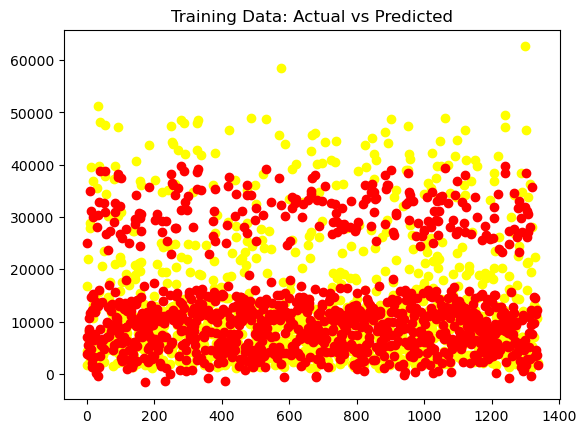

In [70]:
import matplotlib.pyplot as plt
plt.figure()
plt.scatter(x=X_train.index,y=y_train,color="yellow")
plt.scatter(x=X_train.index,y=y_pred_train,color="red")
plt.title("Training Data: Actual vs Predicted")
plt.savefig("plot.png")
plt.show()

In [61]:
y_pred_test = charges_predict.predict(X_test)
test_error = mean_squared_error(y_test, y_pred_test)
test_r2 = r2_score(y_test, y_pred_test)

In [62]:
test_error

35478020.67523563

In [63]:
test_r2

0.8069287081198011

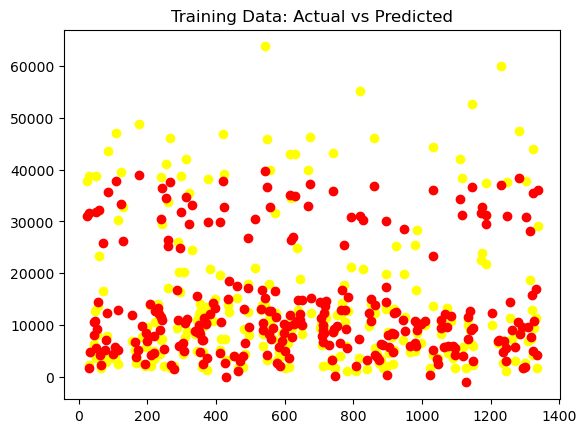

In [71]:
plt.figure()
plt.scatter(x=X_test.index,y=y_test,color="yellow")
plt.scatter(x=X_test.index,y=y_pred_test,color="red")
plt.title("Training Data: Actual vs Predicted")
plt.savefig("plot.png")
plt.show()

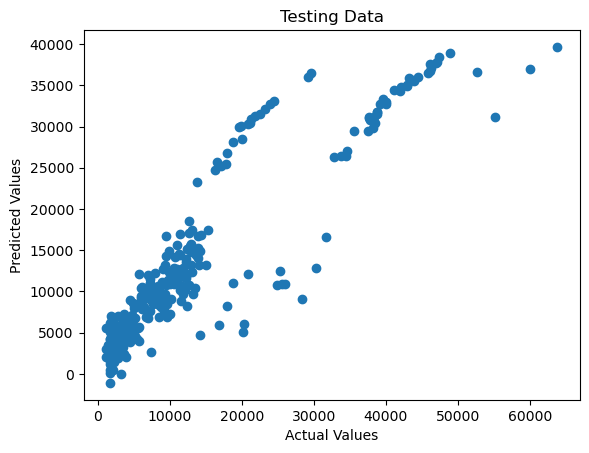

In [66]:
plt.figure()
plt.scatter(y_test, y_pred_test)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Testing Data")
plt.show()